In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

**Linear Spatial Filtering**

In [ ]:
# Read the image in grayscale mode
img = cv2.imread('/content/inputimage.png', 0)
# 0 means image will be loaded as black and white

# Get image dimensions
# m -> no.of rows (height)
# n -> no. of columns (width)

m, n = img.shape

# Create a 3x3 matrix filled with 1s
mask = np.ones([3, 3], dtype=int)

# Divide each value by 9 -> makes average (since 3x3 = 9 elements)
# It is a averaging filter

mask = mask / 9

# Create a new image of same size filled with zeros
# It stores biurred result
img_new = np.zeros([m, n])

# -------------------------
# Apply filter (convolution)
# -------------------------

# Loop through each pixel (skip borders to avoid errors)
for i in range(1, m-1):
  for j in range(1, n-1):

    # Multiply each neighboring pixel with mask value
    temp = (
        img[i-1, j-1] * mask[0, 0] + # top-left
        img[i-1, j] * mask[0, 1] + #top
        img[i-1, j+1] * mask[0, 2] + #top right

        img[i, j-1] * mask[1, 0] + #left
        img[i, j] * mask[1, 1] + #center
        img[i, j+1] * mask[1, 2] + #right

        img[i+1, j-1] * mask[2, 0] + #bottom left
        img[i+1, j] * mask[2, 1] + #bottom
        img[i+1, j+1] * mask[2, 2] #bottom right
    )

    # Store the computed value in the new image
    img_new[i, j] = temp

#--------------------
# Final step
#--------------------

# Convert values to unsigned 8-bit integers (0-255)
img_new = img_new.astype(np.uint8)

# Save the output image
cv2.imwrite('Averaging filtered image.tif', img_new)

True

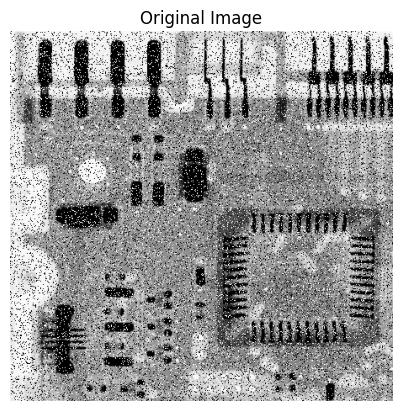

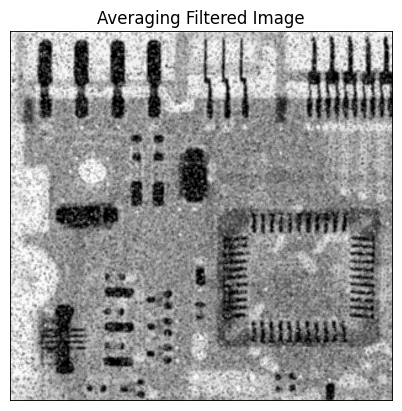

In [ ]:
# Display the original image
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Display the blurred image using matplotlib
plt.imshow(img_new, cmap='gray')
plt.title('Averaging Filtered Image')
plt.axis('off') # Hide axes for a cleaner look
plt.show()

**Guassian Filter**

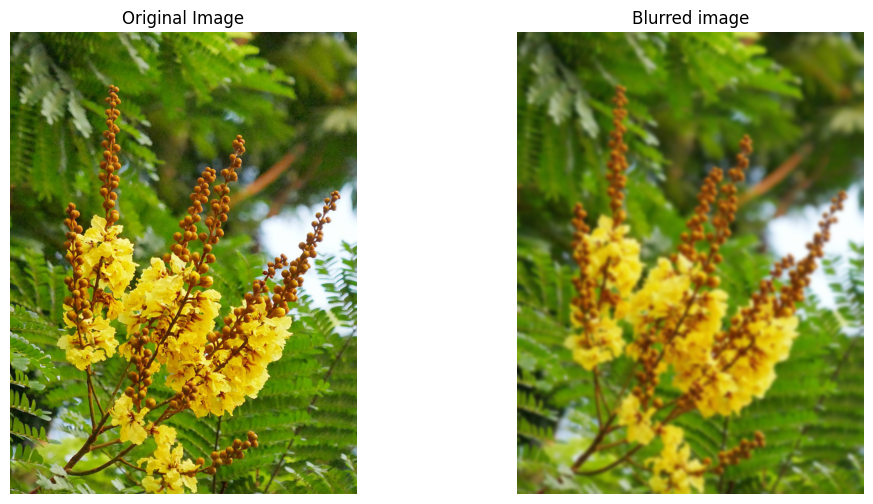

In [ ]:
# Load the image
image = cv2.imread('/content/PEL-PTE-s5-4-600x800.jpg', cv2.IMREAD_COLOR)

# Convert from BGR to RGB for correct color display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply Gaussian filter
kernal_size = (15, 15)
sigma_value = 0 # sigma defines the blur strength
guassian_blur = cv2.GaussianBlur(image_rgb, kernal_size, sigma_value)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Display the blurred image
axes[1].imshow(guassian_blur)
axes[1].set_title('Blurred image')
axes[1].axis('off')

plt.show()

**Laplacian Filter**

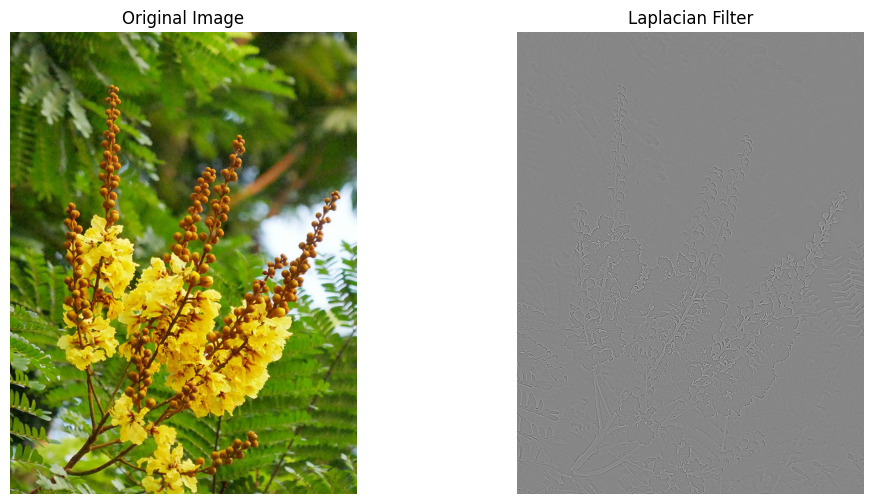

In [ ]:
# Convert image to grayscale
# This filter is ofetn designed to oprate on a single channel
image = cv2.imread('/content/PEL-PTE-s5-4-600x800.jpg', cv2.IMREAD_COLOR)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Laplacian filter
# cv2.CV_64 specifies the output data type as 64-bit
# The laplacian can produce both positive an negative values.

laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)

fig, axis = plt.subplots(1, 2, figsize=(12, 6))
axis[0].imshow(image_rgb, cmap='gray')
axis[0].set_title('Original Image')
axis[0].axis('off')

axis[1].imshow(laplacian, cmap='gray')
axis[1].set_title('Laplacian Filter')
axis[1].axis('off')

plt.show()

**Order statistics (Non linear filter)**